# Analyse des YawDD-Datensatzes

In [1]:
# Import libraries
import os
import pandas as pd
import torch
from torchvision import transforms
from torchcodec.decoders import VideoDecoder
import matplotlib.pyplot as plt

In [2]:
# Set path to yawdd dataset
path = "../../../../YawDD/YawDD dataset/Mirror"

In [3]:
# Store file paths and names of all videos in separate lists
file_paths = []
file_names = []
for dirpath, dirnames, filenames in os.walk(path):
        for fname in filenames:
            file_paths.append(dirpath+'/'+fname)
            file_names.append(fname[:-4])

# Show file names
file_names

['1-FemaleNoGlasses-Normal',
 '1-FemaleNoGlasses-Talking',
 '1-FemaleNoGlasses-Yawning',
 '10-FemaleNoGlasses-Normal',
 '10-FemaleNoGlasses-Talking',
 '10-FemaleNoGlasses-Yawning',
 '11-FemaleNoGlasses-Normal',
 '11-FemaleNoGlasses-Talking',
 '11-FemaleNoGlasses-Yawning',
 '12-FemaleNoGlasses-Normal',
 '12-FemaleNoGlasses-Talking',
 '12-FemaleNoGlasses-Yawning',
 '13-FemaleNoGlasses-Normal',
 '13-FemaleNoGlasses-Talking',
 '13-FemaleNoGlasses-Yawning',
 '14-FemaleNoGlasses-Normal',
 '14-FemaleNoGlasses-Talking',
 '14-FemaleNoGlasses-Yawning',
 '15-FemaleGlasses-Normal',
 '15-FemaleGlasses-Talking',
 '15-FemaleGlasses-Yawning',
 '15-FemaleSunGlasses-Normal',
 '15-FemaleSunGlasses-Yawning',
 '16-FemaleGlasses-Normal',
 '16-FemaleGlasses-Talking',
 '16-FemaleGlasses-Yawning',
 '17-FemaleNoGlasses-Normal',
 '17-FemaleNoGlasses-Talking',
 '17-FemaleNoGlasses-Yawning',
 '17-FemaleSunGlasses-Normal',
 '17-FemaleSunGlasses-Talking',
 '17-FemaleSunGlasses-Yawning',
 '18-FemaleNoGlasses-Normal',

## Datenaufbereitung - Labels und Metadaten

In [17]:
# Store labels in DataFrame
df = pd.DataFrame([fn.split('-') for fn in file_names], columns=['id', 'info_labels', 'activity'])

# Add file paths
df['filepath'] = file_paths

# Print unique meta data labels
print(df['info_labels'].unique().tolist())

# Print unique acitvity labels
print(df['activity'].unique().tolist())

['FemaleNoGlasses', 'FemaleGlasses', 'FemaleSunGlasses', 'MaleNoGlasses', 'MaleSunGlasses', 'MaleGlasses', 'MaleGlassesmoustache', 'MaleGlassesBeard']
['Normal', 'Talking', 'Yawning', 'Talking&Yawning', 'Talking&yawning']


In [18]:
# Print value counts of meta labels
display(df['info_labels'].value_counts())

# Print value counts of activity labels
df['activity'].value_counts()

info_labels
FemaleNoGlasses         101
MaleNoGlasses            81
MaleGlasses              59
FemaleGlasses            30
FemaleSunGlasses         25
MaleSunGlasses           11
MaleGlassesBeard          7
MaleGlassesmoustache      6
Name: count, dtype: int64

activity
Normal             105
Yawning            102
Talking            100
Talking&Yawning     12
Talking&yawning      1
Name: count, dtype: int64

In [19]:
# Create new columns with meta data
df['gender'] = ['Female' if 'Female' in g else 'Male' for g in df['info_labels']]
df['glasses'] = ['no' if 'NoGlasses' in g else ('sunglasses' if 'SunGlasses' in g else 'glasses') for g in df['info_labels']]
df['facial_hair'] = ['beard' if 'Beard' in g else ('moustache' if 'moustache' in g else 'no') for g in df['info_labels']]

In [20]:
# Get binary activity label
df['yawning'] = ['Y' if 'yawning' in g.lower() else 'N' for g in df['activity']]

# Print value counts
df['yawning'].value_counts()

yawning
N    205
Y    115
Name: count, dtype: int64

In [21]:
# Print sample
df.sample(10)

,id,info_labels,activity,filepath,gender,glasses,facial_hair,yawning
188,2,MaleGlasses,Normal,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,glasses,no,N
216,26,MaleNoGlasses,Normal,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,no,no,N
255,34,MaleNoGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,no,no,N
181,17,MaleNoGlasses,Yawning,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,no,no,Y
208,24,MaleGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,glasses,no,N
62,24,FemaleNoGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,N
288,42,MaleNoGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,no,no,N
240,30,MaleGlasses,Talking&Yawning,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,glasses,no,Y
284,41,MaleNoGlasses,Normal,../../../../YawDD/YawDD dataset/Mirror\Male_mi...,Male,no,no,N
67,25,FemaleSunGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,sunglasses,no,N


## Datenaufbereitung - Input
Hier exemplarisch für ein Video

In [9]:
# Get video frames
decoder = VideoDecoder(file_paths[0])

# Select frame indices
indices = torch.linspace(0, decoder.metadata.num_frames - 1, steps=10).long()

# Get raw image frames
raw_frames = decoder.get_frames_at(indices=list(indices)).data

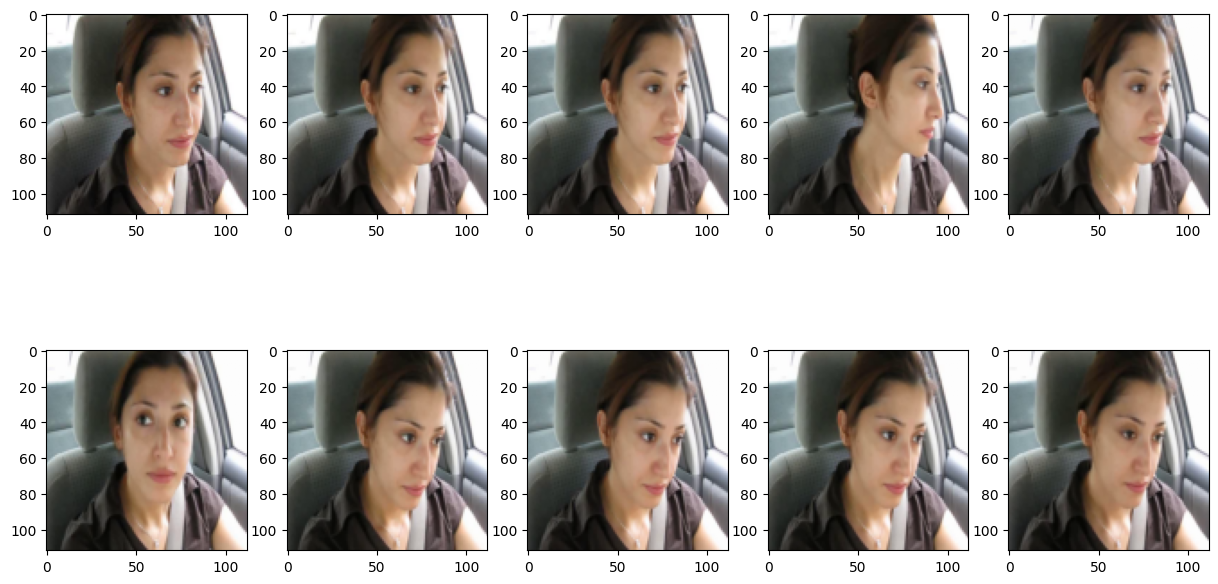

In [10]:
# Define transforms
img_transforms = transforms.Compose([
    transforms.ToPILImage(),          # C×H×W tensor → PIL Image
    transforms.Resize((128, 128)),    # resize
    transforms.CenterCrop(112),       # crop
    transforms.ToTensor(),            # back to C×H×W tensor
])

# Prepare a figure for plotting the video sequence
plt.figure(figsize=(15,8))

# Plot resized frames
k = 1
for frame in raw_frames:
    plt.subplot(2,5,k)
    resized = img_transforms(frame)                    
    plt.imshow(resized.permute(1, 2, 0).numpy())
    k+=1
plt.show()

In [11]:
# Print the shape of a single resized frame
print(resized.shape)

torch.Size([3, 112, 112])


## Datenaufteilung

In [25]:
from sklearn.model_selection import train_test_split

In [22]:
df.head()

,id,info_labels,activity,filepath,gender,glasses,facial_hair,yawning
0,1,FemaleNoGlasses,Normal,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,N
1,1,FemaleNoGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,N
2,1,FemaleNoGlasses,Yawning,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,Y
3,10,FemaleNoGlasses,Normal,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,N
4,10,FemaleNoGlasses,Talking,../../../../YawDD/YawDD dataset/Mirror\Female_...,Female,no,no,N


In [ ]:
# Split data
df_train, df_test = train_test_split(df, test_size=0.1, stratify=df['yawning'], random_state=42)
df_train, df_val = train_test_split(df_train, test_size=0.1, stratify=df_train['yawning'], random_state=42)

print(f'Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')

Train: 259, Val: 29, Test: 32


Todo: Bei der Aufteilung muss die Personen-ID berücksichtigt werden, um "data leakage" zu vermeiden".